In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 2.5.0
Pandas: 3.0.3
Scikit-learn: 1.9.0


In [6]:
import pandas as pd

df = pd.read_excel("../datasets/flood_dataset.xlsx")
df.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 115
Columns : 11


In [8]:
df.columns

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='str')

In [9]:
df.dtypes

Temp             int64
Humidity         int64
Cloud Cover      int64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temp,115.0,29.600000,1.122341,28.0,29.000000,30.000000,31.000000,31.000000
Humidity,115.0,73.852174,2.947623,70.0,71.000000,74.000000,76.000000,79.000000
Cloud Cover,115.0,36.286957,4.330158,30.0,32.500000,36.000000,40.000000,44.000000
ANNUAL,115.0,2925.487826,422.112193,2068.8,2627.900000,2937.500000,3164.100000,4257.800000
Jan-Feb,115.0,27.739130,22.361032,0.3,10.250000,20.500000,41.600000,98.100000
Mar-May,115.0,377.253913,151.091850,89.9,276.750000,342.000000,442.300000,915.200000
Jun-Sep,115.0,2022.840870,386.254397,1104.3,1768.850000,1948.700000,2242.900000,3451.300000
Oct-Dec,115.0,497.636522,129.860643,166.6,407.450000,501.500000,584.550000,823.300000
avgjune,115.0,218.100870,62.547597,65.6,179.666667,211.033333,263.833333,366.066667
sub,115.0,439.801739,210.438813,34.2,295.000000,430.600000,577.650000,982.700000


In [12]:
df.isnull().sum()

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

In [13]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().sum()/len(df)*100,2)
})

missing

,Missing Values,Percentage
Temp,0,0.0
Humidity,0,0.0
Cloud Cover,0,0.0
ANNUAL,0,0.0
Jan-Feb,0,0.0
Mar-May,0,0.0
Jun-Sep,0,0.0
Oct-Dec,0,0.0
avgjune,0,0.0
sub,0,0.0


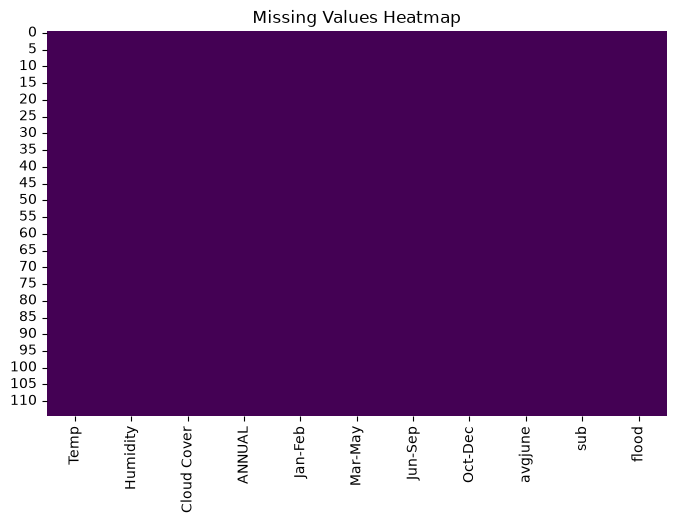

In [14]:
plt.figure(figsize=(8,5))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

In [15]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [16]:
df["flood"].value_counts()

flood
0    99
1    16
Name: count, dtype: int64

In [17]:
round(df["flood"].value_counts(normalize=True)*100,2)

flood
0    86.09
1    13.91
Name: proportion, dtype: float64

C:\Users\yakaa\AppData\Local\Temp\ipykernel_19220\2668147614.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


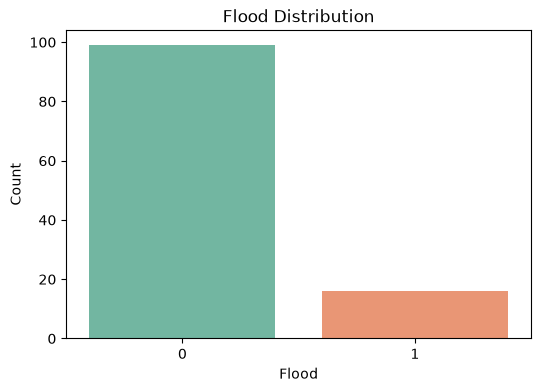

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="flood",
    palette="Set2"
)

plt.title("Flood Distribution")

plt.xlabel("Flood")

plt.ylabel("Count")

plt.show()

In [19]:
num_cols = df.select_dtypes(include=np.number).columns

num_cols

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='str')

In [20]:
cat_cols = df.select_dtypes(include="object").columns

cat_cols

Index([], dtype='str')

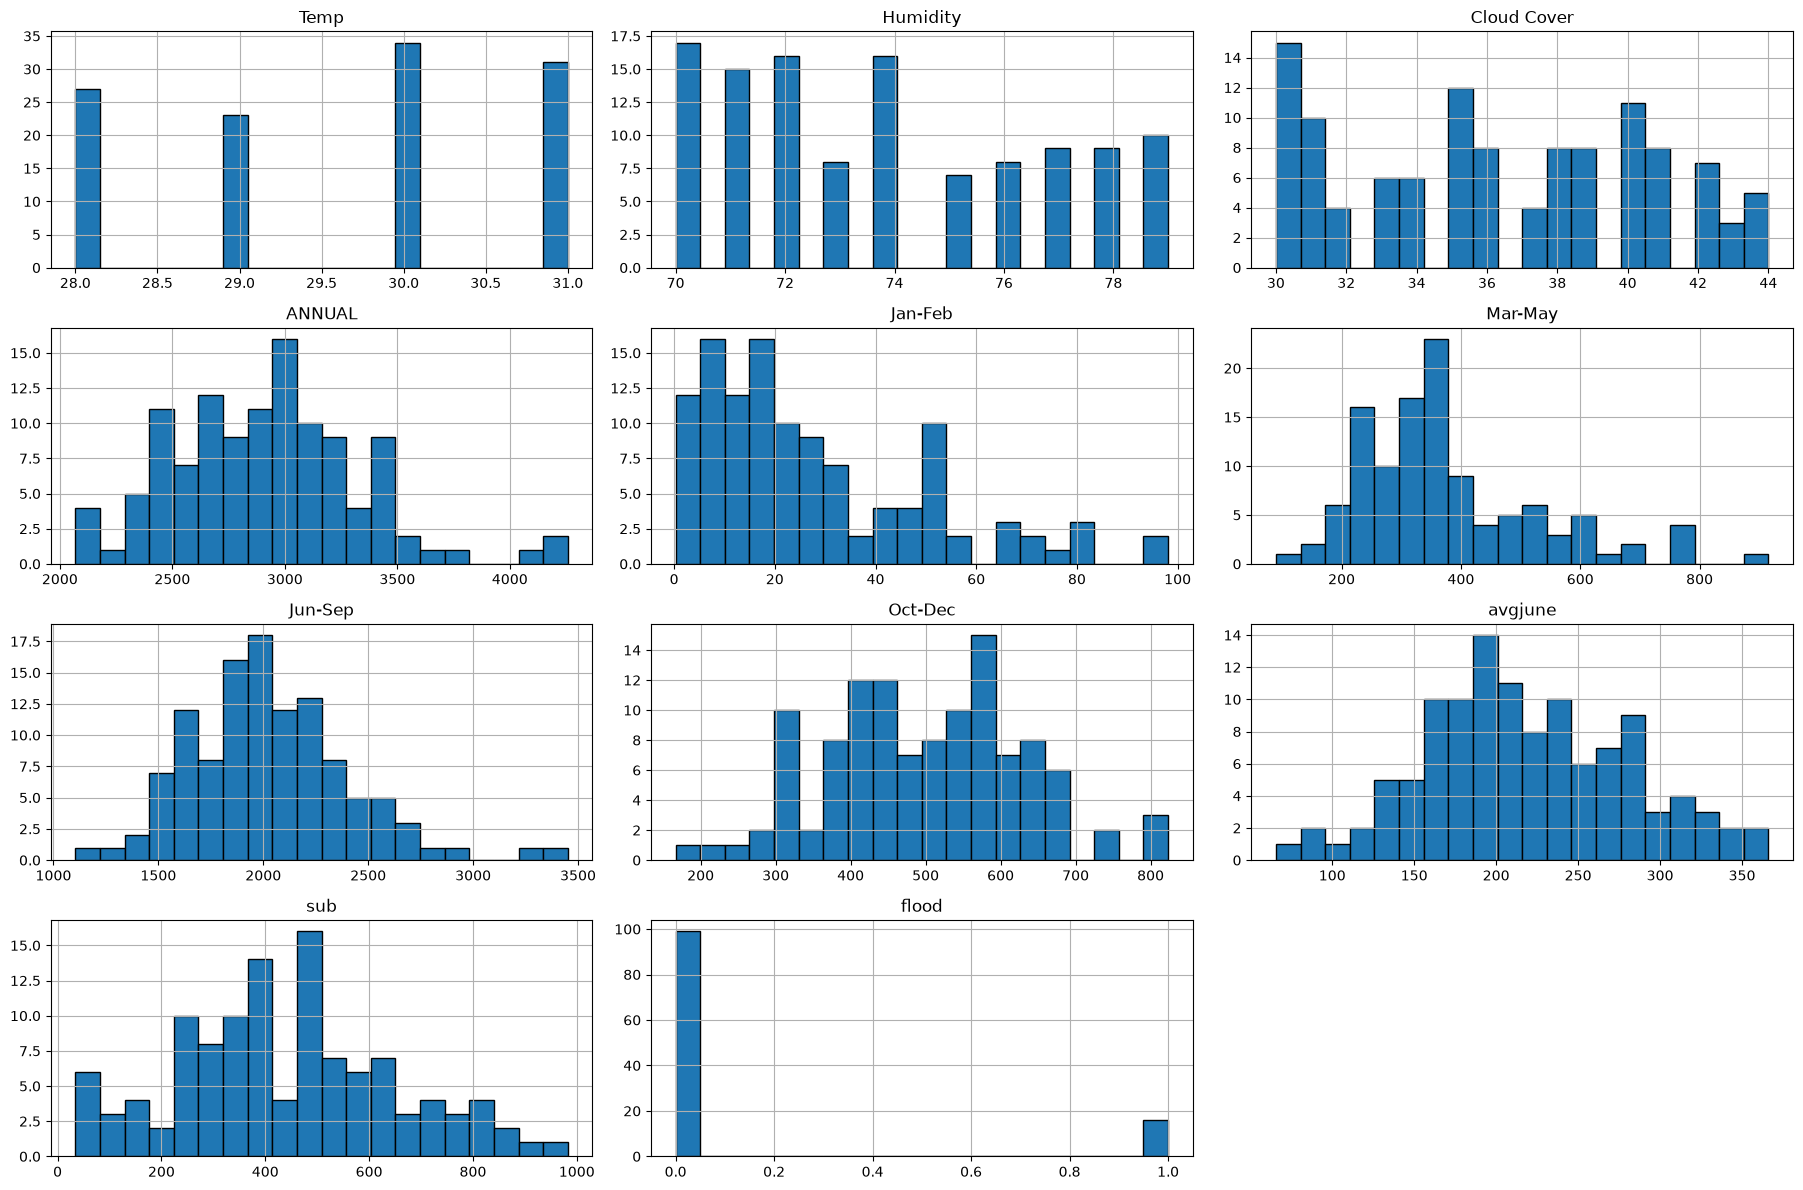

In [21]:
df.hist(
    figsize=(18,12),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()

plt.show()

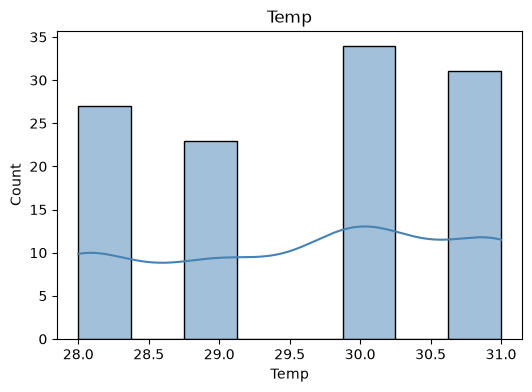

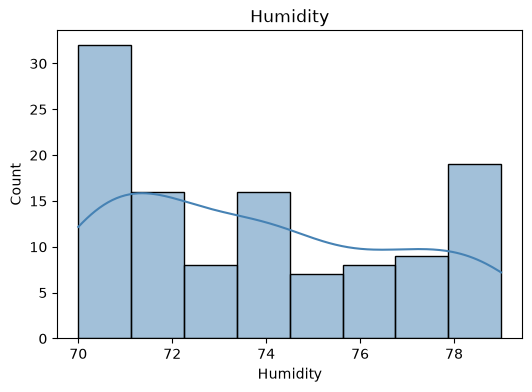

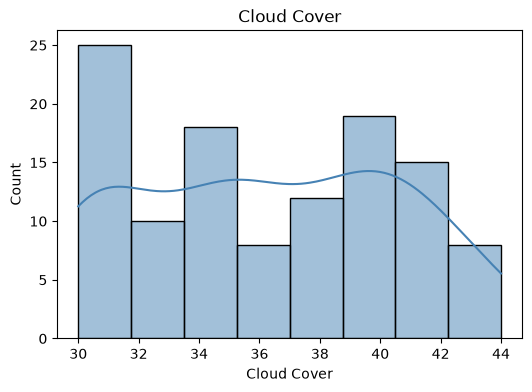

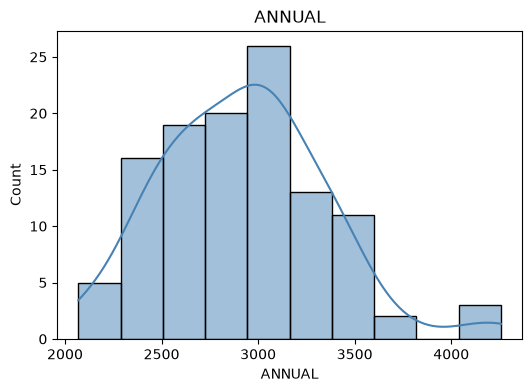

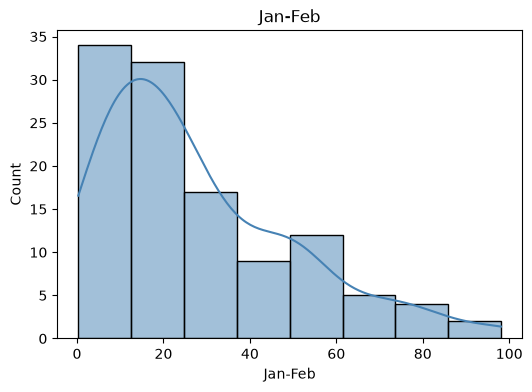

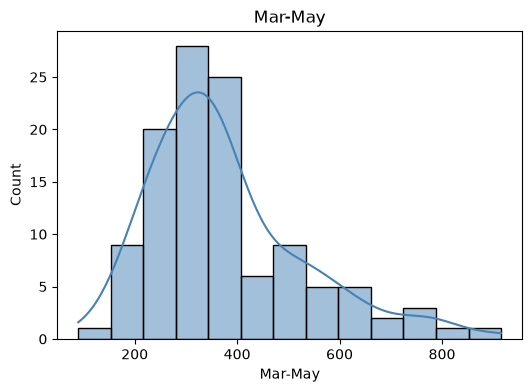

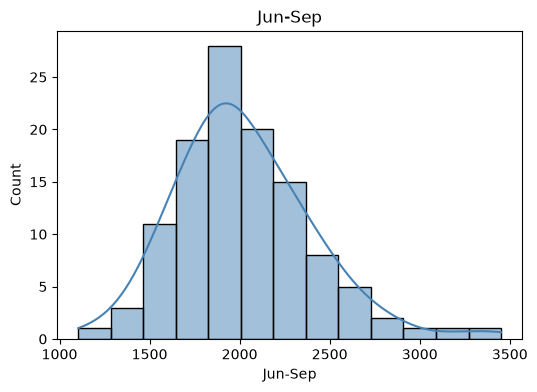

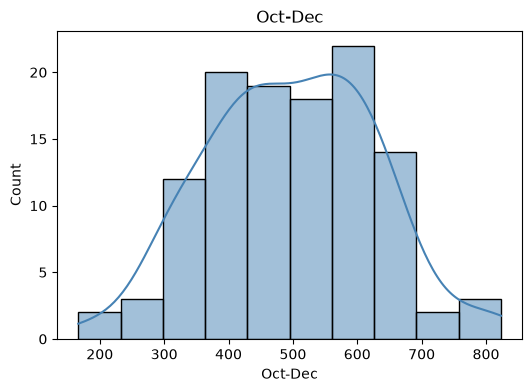

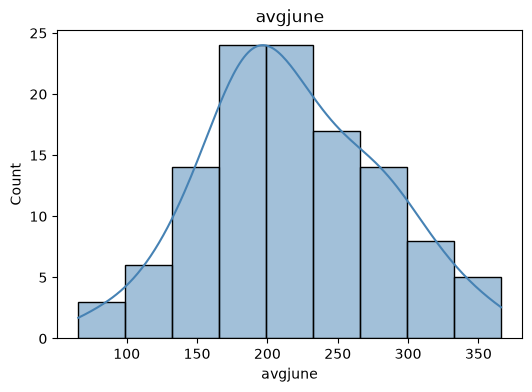

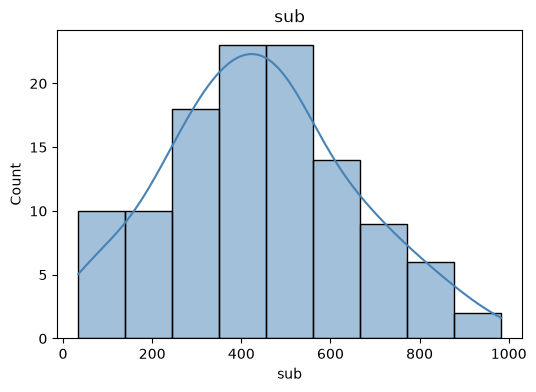

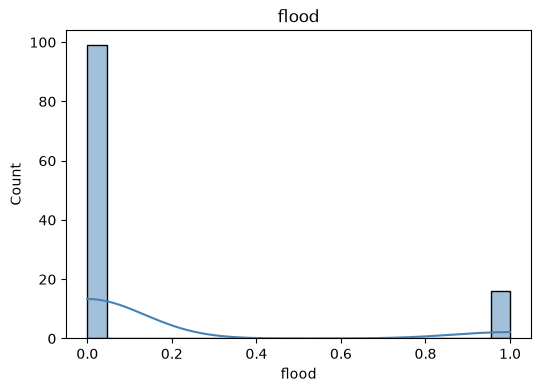

In [22]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True,
        color="steelblue"
    )

    plt.title(col)

    plt.show()

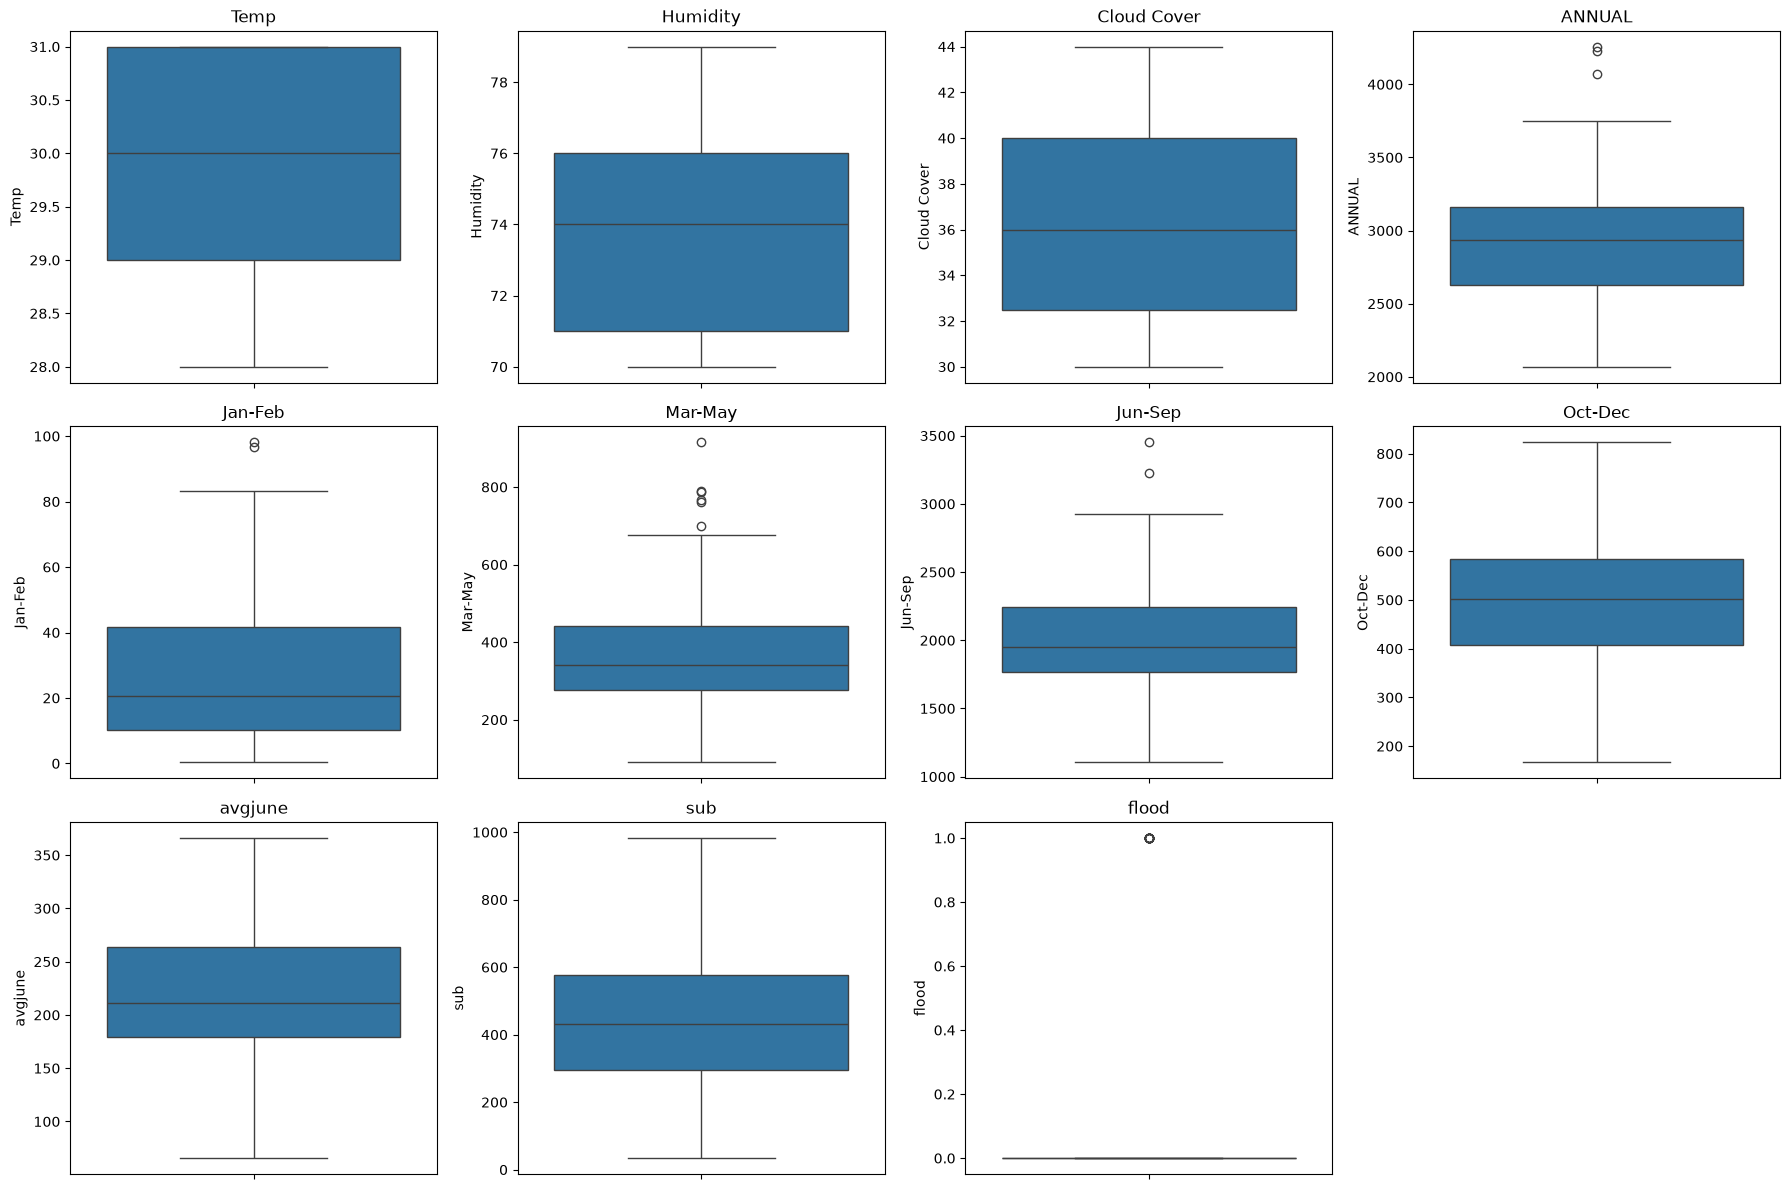

In [23]:
plt.figure(figsize=(18,12))

for i,col in enumerate(num_cols):

    plt.subplot(3,4,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [24]:
corr = df.corr(numeric_only=True)

corr

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
Temp,1.000000,-0.012727,-0.046568,-0.063014,-0.080076,0.099519,-0.081965,-0.063034,-0.019751,-0.088331,-0.080946
Humidity,-0.012727,1.000000,0.085824,-0.054767,-0.185965,-0.101232,-0.029583,0.059739,0.017656,0.029981,0.020250
Cloud Cover,-0.046568,0.085824,1.000000,0.051166,0.004376,0.096645,0.010833,0.020966,-0.089843,-0.106455,0.089801
ANNUAL,-0.063014,-0.054767,0.051166,1.000000,0.033639,0.387790,0.861190,0.232069,0.474644,0.220009,0.626874
Jan-Feb,-0.080076,-0.185965,0.004376,0.033639,1.000000,0.066479,0.001178,-0.143670,0.164691,0.201266,-0.084446
Mar-May,0.099519,-0.101232,0.096645,0.387790,0.066479,1.000000,-0.029007,0.171805,0.019183,-0.475750,-0.017598
Jun-Sep,-0.081965,-0.029583,0.010833,0.861190,0.001178,-0.029007,1.000000,-0.141467,0.511113,0.431997,0.705202
Oct-Dec,-0.063034,0.059739,0.020966,0.232069,-0.143670,0.171805,-0.141467,1.000000,-0.028055,-0.050862,-0.024852
avgjune,-0.019751,0.017656,-0.089843,0.474644,0.164691,0.019183,0.511113,-0.028055,1.000000,0.780445,0.379778
sub,-0.088331,0.029981,-0.106455,0.220009,0.201266,-0.475750,0.431997,-0.050862,0.780445,1.000000,0.349828


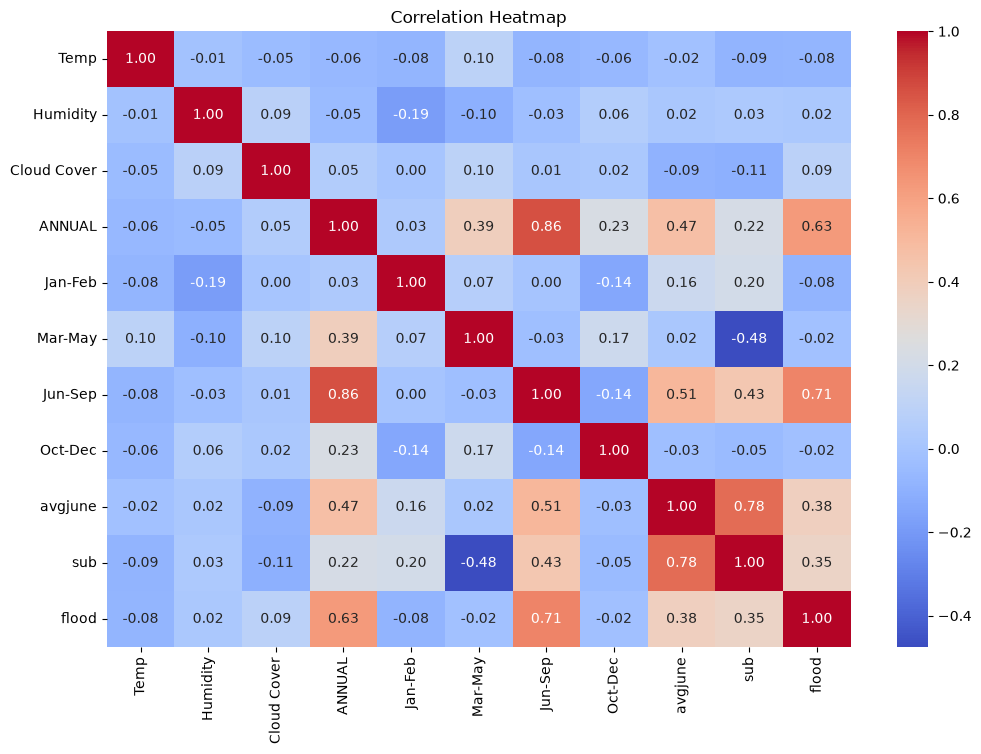

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [26]:
for col in df.columns:

    print(f"\n{col}")

    print(df[col].unique())

    print("-"*50)


Temp
[29 28 31 30]
--------------------------------------------------

Humidity
[70 75 71 74 78 73 77 79 72 76]
--------------------------------------------------

Cloud Cover
[30 40 42 44 38 36 34 32 35 33 31 43 41 37 39]
--------------------------------------------------

ANNUAL
[3248.6 3326.6 3271.2 3129.7 2741.6 2708.  3671.1 2648.3 3050.2 2848.6
 2726.7 3451.3 2610.8 2899.1 3024.5 2945.3 2704.8 2501.9 3003.3 3303.1
 2719.9 3267.6 3484.7 4226.4 3062.1 2965.4 2994.7 2502.8 3361.6 3018.
 3259.6 3403.  4072.9 2410.7 2498.2 3043.3 2818.2 2634.1 2937.5 3117.8
 3111.1 3050.9 3464.2 2490.  2432.4 3565.5 2998.1 3039.2 2942.6 3146.6
 2705.5 2334.8 2544.9 2938.  3134.7 2798.4 3103.3 2923.1 3746.  3385.5
 4257.8 3375.8 2651.1 2869.1 2342.4 2621.7 2569.1 3392.7 2665.  2703.5
 3076.8 2739.4 2412.5 2767.4 3498.4 2068.8 3047.6 3176.7 2503.  2803.4
 3005.9 2223.3 2320.3 2762.1 2390.5 2093.2 2137.6 2403.5 2422.7 2693.1
 3184.5 3239.5 2717.7 3410.8 2858.8 2610.  3252.4 3151.5 2914.6 2412.6
 2931.1 

In [27]:
print("="*50)
print("EDA SUMMARY")
print("="*50)

print(f"Dataset Shape : {df.shape}")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Rows : {df.duplicated().sum()}")

print("\nFlood Distribution")
print(df["flood"].value_counts())

print("\nCorrelation with Flood")
print(corr["flood"].sort_values(ascending=False))

EDA SUMMARY
Dataset Shape : (115, 11)
Missing Values : 0
Duplicate Rows : 0

Flood Distribution
flood
0    99
1    16
Name: count, dtype: int64

Correlation with Flood
flood          1.000000
Jun-Sep        0.705202
ANNUAL         0.626874
avgjune        0.379778
sub            0.349828
Cloud Cover    0.089801
Humidity       0.020250
Mar-May       -0.017598
Oct-Dec       -0.024852
Temp          -0.080946
Jan-Feb       -0.084446
Name: flood, dtype: float64
